In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers,Sequential

In [ ]:
df = pd.read_csv('/content/ma_lga_12345 (1).csv')

In [ ]:
df.head()

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   saledate  347 non-null    object
 1   MA        347 non-null    int64 
 2   type      347 non-null    object
 3   bedrooms  347 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.0+ KB


In [ ]:
df.isnull().sum()

,0
saledate,0
MA,0
type,0
bedrooms,0


In [ ]:
df.describe()

,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


In [ ]:
df.nunique()

,0
saledate,51
MA,321
type,2
bedrooms,5


In [ ]:
df['saledate'] = pd.to_datetime(df['saledate'])
df.sort_values(by = 'saledate',inplace = True)
df.set_index(df['saledate'],inplace = True)

<ipython-input-142-b7c71bf27ec3>:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['saledate'] = pd.to_datetime(df['saledate'])


In [ ]:
df.head()

,saledate,MA,type,bedrooms
saledate,,,,
2007-03-31,2007-03-31,421291,house,3
2007-03-31,2007-03-31,548969,house,4
2007-06-30,2007-06-30,421291,house,3
2007-06-30,2007-06-30,368817,unit,2
2007-06-30,2007-06-30,548969,house,4


In [ ]:
df = df.drop(columns = 'saledate')
df.head()

,MA,type,bedrooms
saledate,,,
2007-03-31,421291,house,3
2007-03-31,548969,house,4
2007-06-30,421291,house,3
2007-06-30,368817,unit,2
2007-06-30,548969,house,4


<BarContainer object of 347 artists>

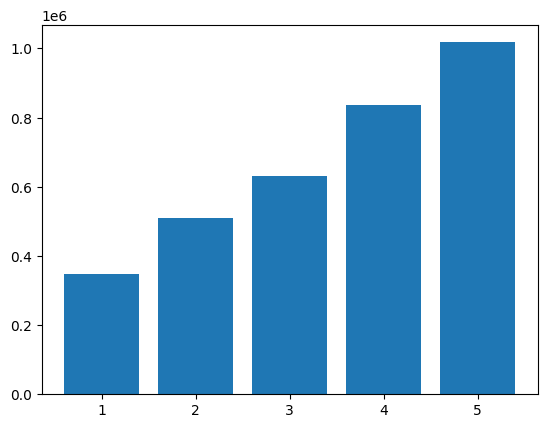

In [ ]:
plt.bar(df.bedrooms,df.MA)

<BarContainer object of 347 artists>

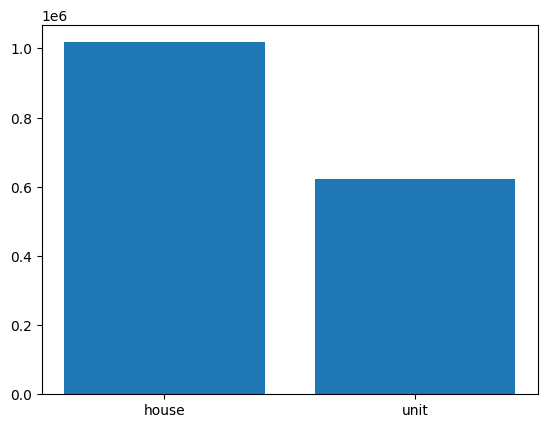

In [ ]:
plt.bar(df.type,df.MA)

<Axes: xlabel='saledate', ylabel='MA'>

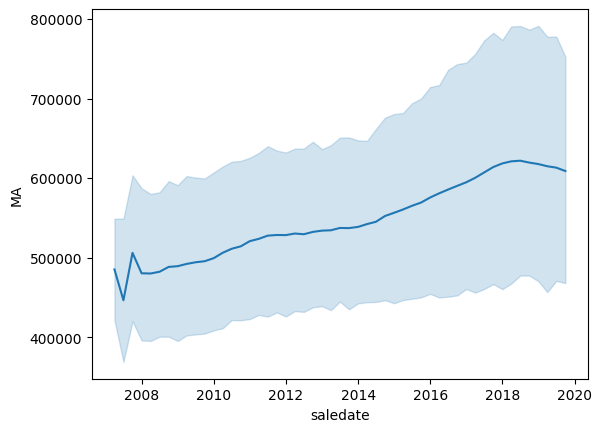

In [ ]:
sns.lineplot(x = 'saledate',y = 'MA',data = df)

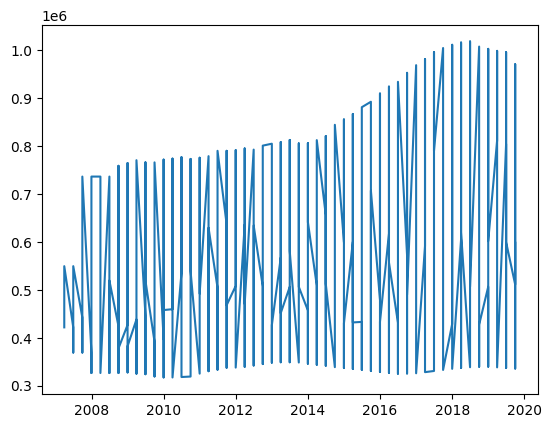

In [ ]:
plt.plot(df.index,df.MA)

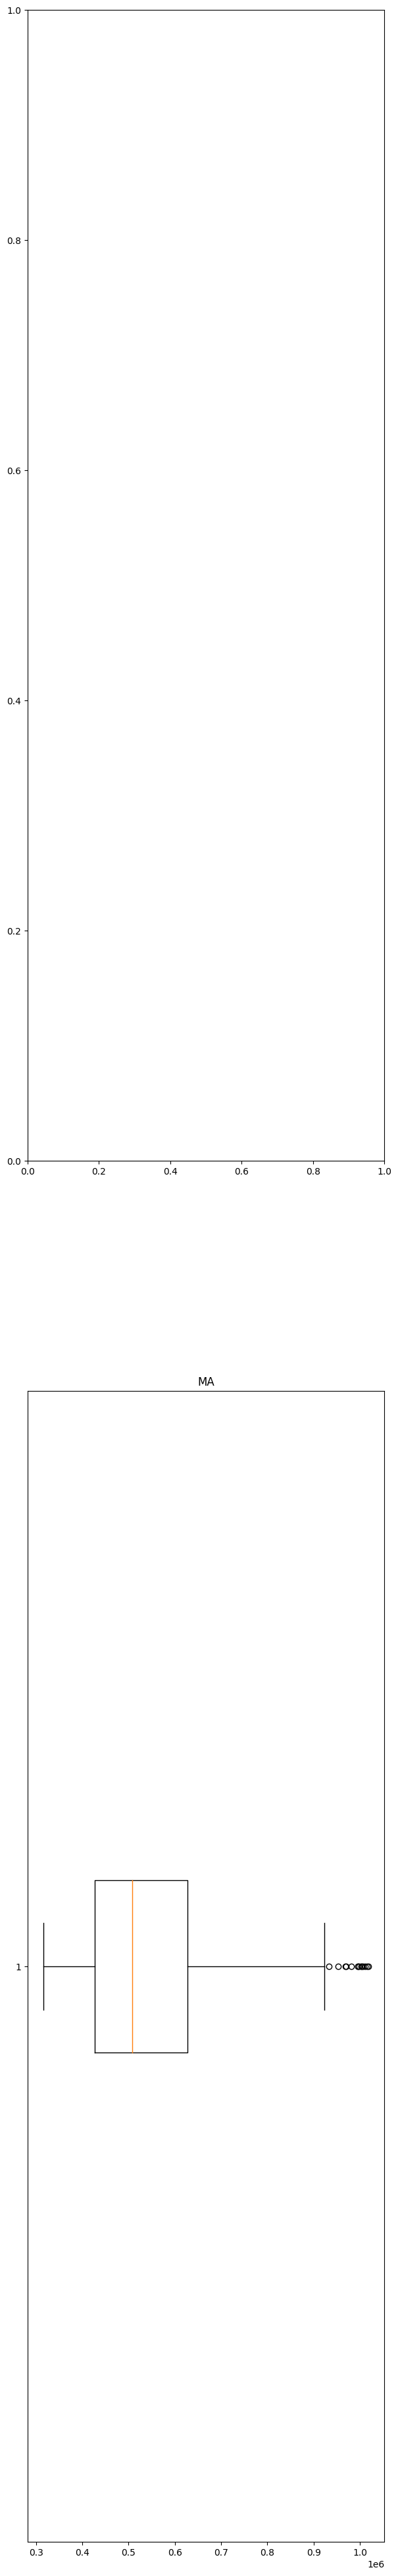

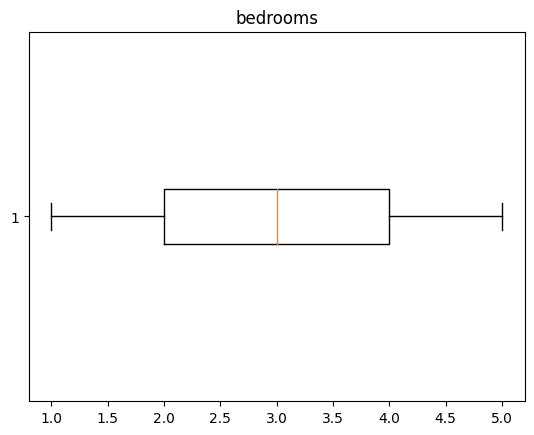

In [ ]:
num_col = [col for col in df.columns if df[col].dtype != 'object']

fig,axs = plt.subplots(len(num_col),1,figsize = (7,50))

for i,j in zip(num_col,range(len(num_col))):
  plt.title(i)
  axs[j] = plt.boxplot(df[i],vert = False)
  plt.show()

In [ ]:
mean = np.mean(df.MA)
std = np.std(df.MA)

lower = mean - 2 * std
upper = mean + 2 * std

df2 = df[(df.MA >= lower) & (df.MA <= upper)]

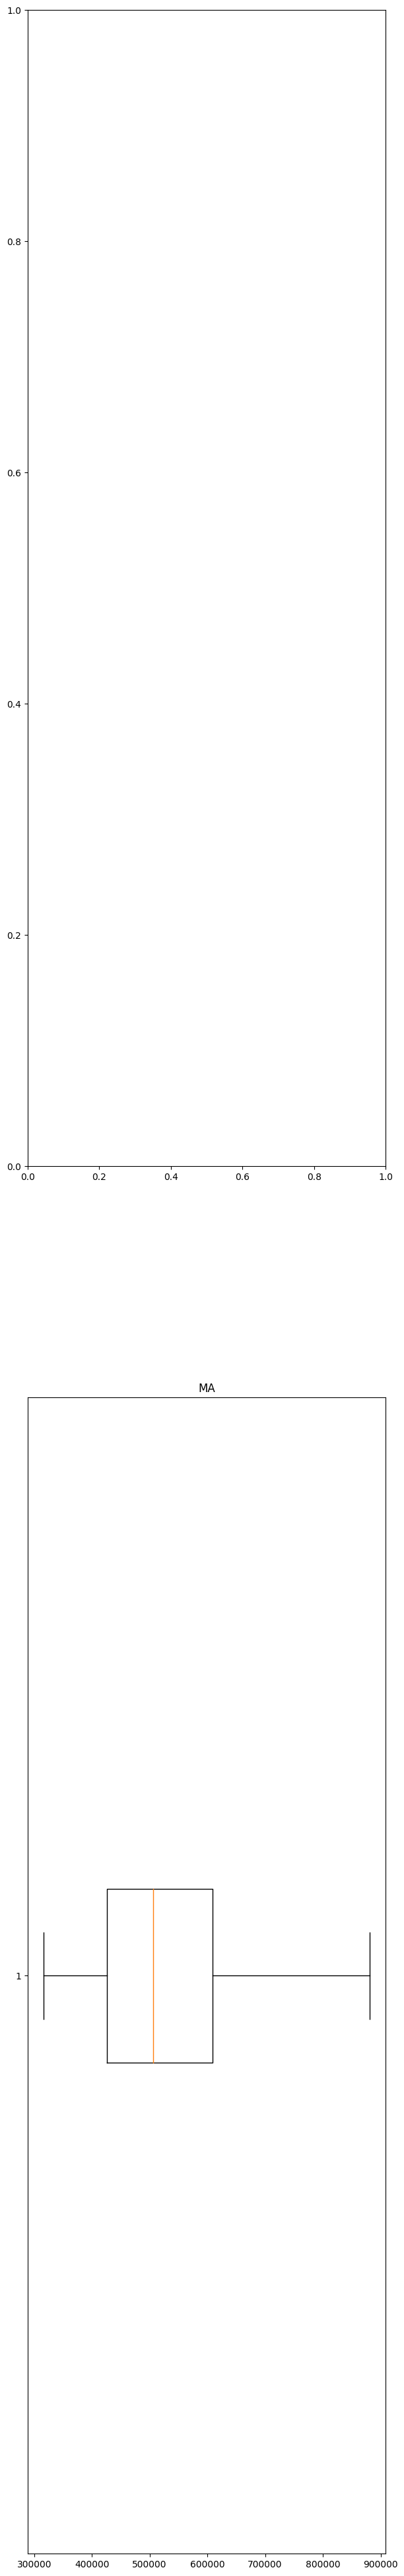

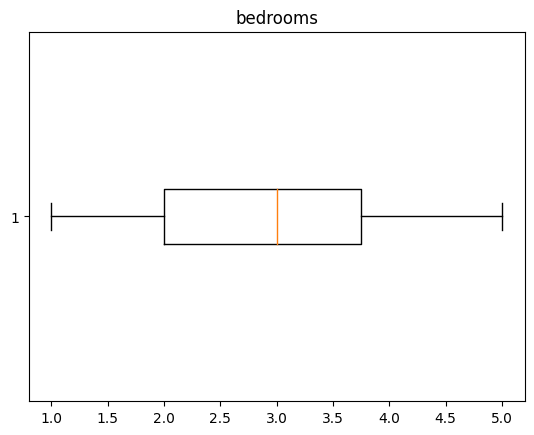

In [ ]:
num_col = [col for col in df2.columns if df2[col].dtype != 'object']

fig,axs = plt.subplots(len(num_col),1,figsize = (7,50))

for i,j in zip(num_col,range(len(num_col))):
  plt.title(i)
  axs[j] = plt.boxplot(df2[i],vert = False)
  plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_col = [col for col in df2.columns if df2[col].dtype == 'object']

encoder = LabelEncoder()

for col in cat_col:
  df2[col] = encoder.fit_transform(df2[col])

df2.head()

<ipython-input-152-d42db53f072b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[col] = encoder.fit_transform(df2[col])


,MA,type,bedrooms
saledate,,,
2007-03-31,421291,0,3
2007-03-31,548969,0,4
2007-06-30,421291,0,3
2007-06-30,368817,1,2
2007-06-30,548969,0,4


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df2)

scaled_pd = pd.DataFrame(scaled,columns = df2.columns,index = df2.index)

scaled_pd.head()

,MA,type,bedrooms
saledate,,,
2007-03-31,0.185396,0.0,0.50
2007-03-31,0.411826,0.0,0.75
2007-06-30,0.185396,0.0,0.50
2007-06-30,0.092336,1.0,0.25
2007-06-30,0.411826,0.0,0.75


In [ ]:
X = scaled_pd.drop(columns = 'MA')
y = scaled_pd.MA

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(264, 2)
(66, 2)


In [ ]:
X_train = X_train.values.reshape([X_train.shape[0],X_train.shape[1],1])
X_test = X_test.values.reshape([X_test.shape[0],X_test.shape[1],1])

In [ ]:
model = Sequential([
    layers.LSTM(200,activation = 'relu',input_shape = (X_train.shape[1],1)),
    layers.Dense(1)
])

model.compile(loss = 'mse',optimizer = 'adam',metrics = ['accuracy'])

model.fit(X_train,y_train,epochs = 5,validation_data = (X_test,y_test))

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.0046 - loss: 0.1982 - val_accuracy: 0.0000e+00 - val_loss: 0.1745
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0021 - loss: 0.1518 - val_accuracy: 0.0000e+00 - val_loss: 0.1349
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0021 - loss: 0.1089 - val_accuracy: 0.0000e+00 - val_loss: 0.1026
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0027 - loss: 0.0792 - val_accuracy: 0.0000e+00 - val_loss: 0.0819
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0093 - loss: 0.0737 - val_accuracy: 0.0000e+00 - val_loss: 0.0717


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [ ]:
model = ARIMA(scaled_pd['MA'],order = (1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                     MA   No. Observations:                  330
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -12.921
Date:                Mon, 07 Oct 2024   AIC                             31.841
Time:                        14:00:20   BIC                             43.229
Sample:                             0   HQIC                            36.384
                                - 330                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1608      0.061     -2.644      0.008      -0.280      -0.042
ma.L1         -0.9827      0.013    -75.761      0.000      -1.008      -0.957
sigma2         0.0626      0.006     11.181      0.0

In [ ]:
forecast = model_fit.forecast(steps = 5)
print(forecast)

330    0.389148
331    0.406742
332    0.403913
333    0.404368
334    0.404295
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
!pip install pmdarima

In [ ]:
from pmdarima import auto_arima

auto_model = auto_arima(scaled_pd['MA'],start_p = 1,start_q = 1,max_p = 1,max_q = 1,d = 1)

print(auto_model.summary)

forecast_auto = auto_model.predict(n_periods = 5)
print(forecast_auto)

<bound method ARIMA.summary of ARIMA(order=(1, 1, 1), scoring_args={}, suppress_warnings=True,
      with_intercept=False)>
330    0.389148
331    0.406742
332    0.403913
333    0.404368
334    0.404295
dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
from prophet import Prophet

scaled_pd = scaled_pd.rename(columns = {'MA' : 'y'})
scaled_pd['ds'] = scaled_pd.index

model = Prophet()
model.fit(scaled_pd)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1rf3p0__/nwr_u4pv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1rf3p0__/fa67g_rn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57821', 'data', 'file=/tmp/tmp1rf3p0__/nwr_u4pv.json', 'init=/tmp/tmp1rf3p0__/fa67g_rn.json', 'output', 'file=/tmp/tmp1rf3p0__/prophet_modelb56oprhs/prophet_model-20241007140023.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:00:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:00:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods = 30)

forecast = model.predict(future)

print(forecast)

           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0  2007-03-31  0.229011    0.018929    0.637423     0.229011     0.229011   
1  2007-06-30  0.231224   -0.002215    0.624282     0.231224     0.231224   
2  2007-09-30  0.233462    0.007655    0.637598     0.233462     0.233462   
3  2007-12-31  0.235699   -0.006050    0.641535     0.235699     0.235699   
4  2008-03-31  0.237912    0.027811    0.664734     0.237912     0.237912   
..        ...       ...         ...         ...          ...          ...   
76 2019-10-26  0.341109   -0.032280    0.618574     0.341109     0.341109   
77 2019-10-27  0.341134   -0.011920    0.594628     0.341134     0.341134   
78 2019-10-28  0.341158   -0.056719    0.608470     0.341158     0.341158   
79 2019-10-29  0.341182   -0.024608    0.615883     0.341182     0.341182   
80 2019-10-30  0.341207   -0.012365    0.629606     0.341207     0.341207   

    additive_terms  additive_terms_lower  additive_terms_upper    yearly  \